## Passo 4 — Análise exploratória de dados (Python)



Nesta etapa, realizo a análise exploratória dos dados obtidos a partir das consultas SQL.

O objetivo é entender padrões nas corridas de táxi em Chicago, analisando:

- Quantidade de corridas por empresa de táxi
- Bairros mais populares como destino das corridas

Essa análise ajudará a identificar tendências importantes e fornecer contexto para as etapas seguintes do projeto.



### 4.1 — Importação dos arquivos CSV

Os dados foram fornecidos em dois arquivos CSV.  
Cada arquivo foi carregado em um DataFrame utilizando a biblioteca pandas.

In [64]:
import pandas as pd


In [65]:
df_trips_company = pd.read_csv('/datasets/project_sql_result_01.csv')
df_trips_neighborhood = pd.read_csv('/datasets/project_sql_result_04.csv')


### 4.2 — Inspeção inicial dos dados

Para entender melhor a estrutura dos dados, visualizo as primeiras linhas de cada DataFrame.
Isso permite verificar rapidamente o conteúdo das tabelas e confirmar se os dados foram carregados corretamente.

In [66]:
df_trips_company.head()


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [67]:
df_trips_neighborhood.head()


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


### 4.3 — Verificação dos tipos de dados

Nesta etapa, verifico:

- Tipos de dados de cada coluna
- Quantidade de valores não nulos
- Possíveis inconsistências estruturais

In [68]:
df_trips_company.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [69]:
df_trips_neighborhood.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


### Conclusões da verificação dos dados

O conjunto de dados das empresas de táxi possui 64 registros e duas colunas:

- `company_name`: texto com o nome da empresa
- `trips_amount`: número inteiro representando a quantidade de corridas

O conjunto de dados dos bairros possui 94 registros e duas colunas:

- `dropoff_location_name`: texto com o nome do bairro
- `average_trips`: número decimal representando a média de corridas finalizadas no bairro

Com base nessa verificação, concluo que os dados estão prontos para análise exploratória e visualização, sem necessidade de pré-processamento adicional.



### 4.4 — Identificação dos bairros mais populares

Para entender quais regiões recebem maior volume de corridas,
seleciono os 10 bairros com maior média de viagens finalizadas.

In [70]:
top_10_neighborhoods = (
    df_trips_neighborhood
    .sort_values(by='average_trips', ascending=False)
    .head(10)
)

top_10_neighborhoods


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


### Interpretação dos resultados

O bairro **Loop** apresenta o maior número médio de corridas. Isso é esperado, pois é o principal centro financeiro e comercial da cidade, com grande fluxo de pessoas diariamente.

Os bairros **River North** e **Streeterville** aparecem logo em seguida. Essas regiões possuem forte presença de hotéis, restaurantes e atrações turísticas, o que aumenta a demanda por transporte.

O **West Loop** também se destaca, sendo uma área com crescimento comercial e gastronômico nos últimos anos.

O bairro **O'Hare** aparece entre os principais destinos devido ao Aeroporto Internacional O'Hare, que gera grande volume de viagens para embarques e desembarques.

Outros bairros presentes no ranking, como Lake View e Grant Park, indicam demanda associada a lazer, turismo e áreas residenciais com grande circulação de pessoas.


### Conclusão da análise exploratória

A análise exploratória mostrou que a demanda por corridas de táxi em Chicago está fortemente concentrada em:

- Centros comerciais e financeiros, como o Loop
- Regiões turísticas, como River North e Streeterville
- Áreas com grande fluxo de pessoas
- Infraestruturas de transporte, especialmente o Aeroporto Internacional O'Hare

Esses padrões indicam que fatores econômicos, turísticos e logísticos influenciam diretamente o volume de corridas.  
Os resultados obtidos nesta etapa fornecem uma base sólida para análises mais aprofundadas, incluindo a visualização dos dados e o teste de hipóteses nas próximas etapas do projeto.


### 4.5 — Visualização dos dados

Nesta etapa, utilizo gráficos para visualizar os principais resultados da análise exploratória.

Os gráficos ajudam a:
- Comparar o volume de corridas entre empresas de táxi
- Identificar visualmente os bairros mais populares como destino
- Facilitar a interpretação dos padrões encontrados nos dados

In [71]:
import matplotlib.pyplot as plt


### 4.5.1 — Número de corridas por empresa de táxi

O gráfico abaixo mostra a quantidade de corridas realizadas por cada empresa de táxi entre os dias 15 e 16 de novembro de 2017.

Para facilitar a visualização, serão exibidas apenas as empresas com maior número de corridas.

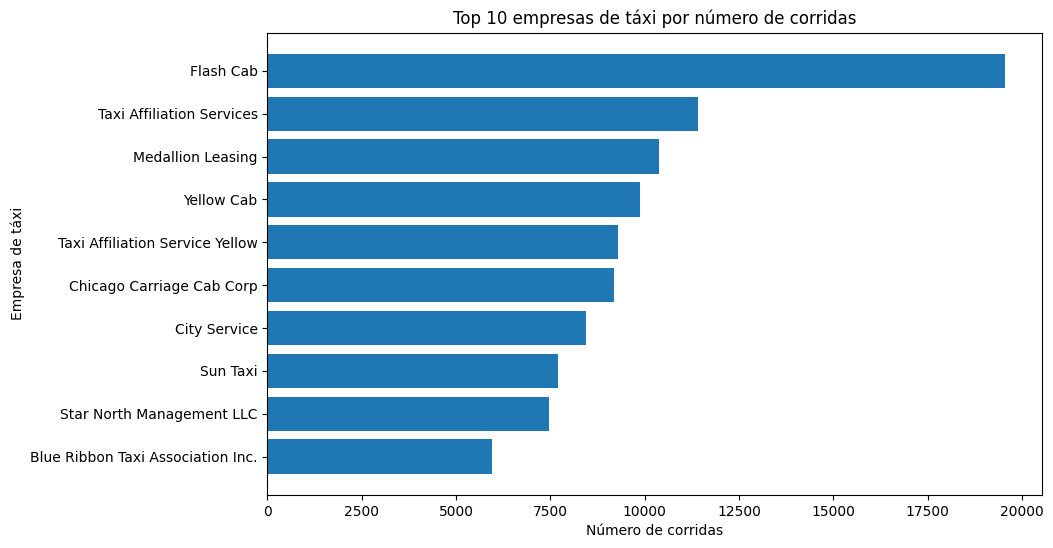

In [72]:
top_companies = df_trips_company.sort_values(
    by='trips_amount', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_companies['company_name'], top_companies['trips_amount'])
plt.xlabel('Número de corridas')
plt.ylabel('Empresa de táxi')
plt.title('Top 10 empresas de táxi por número de corridas')
plt.gca().invert_yaxis()
plt.show()


**Interpretação do gráfico**

O gráfico mostra que a empresa Flash Cab lidera com folga o número de corridas no período analisado.

Em seguida, aparecem Taxi Affiliation Services e Medallion Leasing, indicando que poucas empresas concentram grande parte do mercado.

Esse resultado sugere uma distribuição desigual das corridas, onde grandes empresas dominam o setor de táxis em Chicago.


### 4.5.2 — Top 10 bairros por número médio de corridas

O gráfico abaixo apresenta os 10 bairros com maior média de corridas finalizadas em novembro de 2017.

Esse gráfico ajuda a identificar as regiões mais demandadas como destino das corridas.

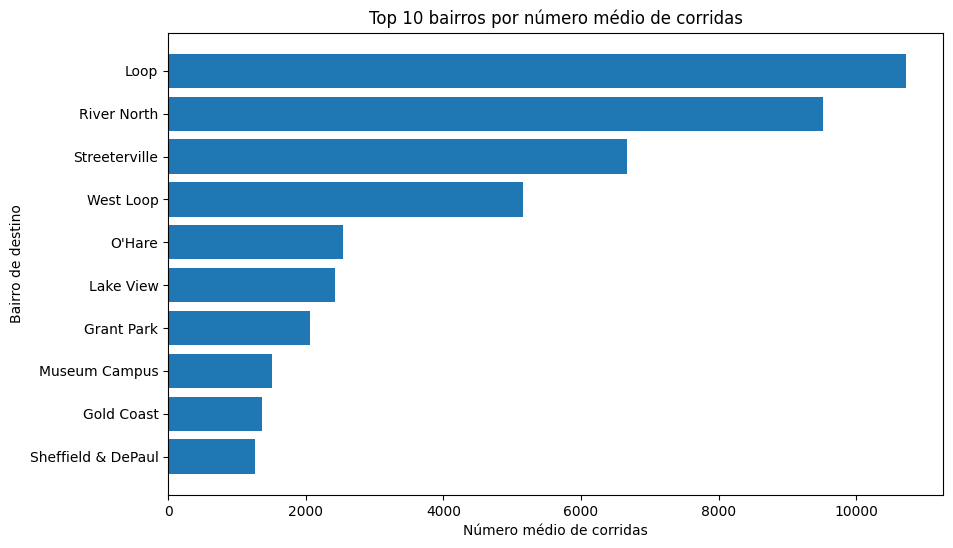

In [73]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_10_neighborhoods['dropoff_location_name'],
    top_10_neighborhoods['average_trips']
)
plt.xlabel('Número médio de corridas')
plt.ylabel('Bairro de destino')
plt.title('Top 10 bairros por número médio de corridas')
plt.gca().invert_yaxis()
plt.show()


**Interpretação do gráfico**

O bairro Loop se destaca como o principal destino das corridas, apresentando uma média muito superior aos demais bairros.

Regiões como River North e Streeterville também aparecem com alta demanda, o que pode ser explicado pela presença de áreas turísticas, hotéis e centros comerciais.

A presença de O'Hare entre os principais destinos reforça a importância do aeroporto na dinâmica das corridas de táxi na cidade.


## Passo 5 — Testando hipóteses (Python)

Nesta etapa, testo a hipótese de que a duração média das corridas do bairro Loop até o Aeroporto Internacional O'Hare muda em sábados chuvosos.

Para isso, utilizo dados sobre:
- Duração das corridas
- Condições meteorológicas no momento da viagem

### 5.1 — Formulação das hipóteses

Hipótese nula (H₀):  
A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é a mesma em sábados com clima bom e em sábados com clima ruim.

Hipótese alternativa (H₁):  
A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é diferente em sábados com clima bom e em sábados com clima ruim.

### 5.2 — Nível de significância

Adoto um nível de significância de 5% (α = 0,05), valor comumente utilizado em análises estatísticas.

Esse valor representa a probabilidade máxima de rejeitar a hipótese nula quando ela é verdadeira.

In [74]:
df_trips_weather = pd.read_csv('/datasets/project_sql_result_07.csv')
df_trips_weather.head()


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


### 5.3 — Inspeção dos dados para o teste de hipóteses

Antes de realizar o teste estatístico, verifico a estrutura do conjunto de dados, os tipos das colunas e a presença de valores ausentes.

In [75]:
df_trips_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


### 5.4 — Preparação dos dados para o teste estatístico

Antes de realizar o teste estatístico, é necessário preparar os dados e verificar se eles atendem às premissas do teste t de Student.

O conjunto de dados possui 1.068 registros e não apresenta valores ausentes, o que garante consistência para a análise.

A coluna `duration_seconds` está em formato numérico (float), permitindo a aplicação de testes estatísticos.

A coluna `weather_conditions` será utilizada para separar as corridas em dois grupos independentes:

- Corridas realizadas em condições climáticas boas (Good)
- Corridas realizadas em dias chuvosos (Bad)

Esses dois grupos serão comparados para verificar se existe diferença estatisticamente significativa na duração média das corridas.

In [76]:
good_weather = df_trips_weather[
    df_trips_weather['weather_conditions'] == 'Good'
]['duration_seconds']

bad_weather = df_trips_weather[
    df_trips_weather['weather_conditions'] == 'Bad'
]['duration_seconds']

len(good_weather), len(bad_weather)

(888, 180)

### 5.4.1 — Análise da variância entre os grupos

Antes de aplicar o teste t de Student, é importante verificar se as variâncias das corridas em dias com clima bom e em dias chuvosos são semelhantes ou diferentes.

Essa verificação é necessária para definir corretamente o parâmetro `equal_var` do teste estatístico.

Para isso, calculo a variância da duração das corridas em cada grupo.

In [77]:
var_good = good_weather.var()
var_bad = bad_weather.var()

print("Variância em dias com clima bom (Good):", var_good)
print("Variância em dias chuvosos (Bad):", var_bad)

Variância em dias com clima bom (Good): 576382.009689509
Variância em dias chuvosos (Bad): 520294.086002483


### Conclusão da preparação dos dados

As variâncias obtidas para os dois grupos foram:

- Dias com clima bom (Good): aproximadamente 576.382
- Dias chuvosos (Bad): aproximadamente 520.294

Apesar de estarem na mesma ordem de grandeza, os valores não são idênticos, indicando que a dispersão da duração das corridas difere entre dias com clima bom e dias chuvosos.

Dessa forma, não é possível assumir igualdade de variâncias.  
Por esse motivo, o teste t de Student será aplicado utilizando o parâmetro `equal_var=False`, que é a abordagem mais adequada para esse cenário.

### 5.5 — Escolha do teste estatístico

Para comparar a duração média das corridas entre dois grupos independentes (clima bom e clima ruim), utilizo o teste t de Student para amostras independentes.

Esse teste é apropriado porque:
- Os dados são numéricos
- Os grupos são independentes entre si
- O objetivo é comparar as médias de dois grupos distintos

Como os tamanhos das amostras são diferentes, utilizo a versão do teste que não assume variâncias iguais.

In [78]:
from scipy import stats

alpha = 0.05


results = stats.ttest_ind(
    good_weather,
    bad_weather,
    equal_var=False
)

results



Ttest_indResult(statistic=-7.186034288068629, pvalue=6.738994326108734e-12)

### 5.6 — Resultados do teste estatístico

O teste t de Student para amostras independentes apresentou os seguintes resultados:

- Estatística t: -7.19
- Valor-p (p-value): 6.74e-12

O valor-p é muito menor que o nível de significância adotado (α = 0.05).

### 5.7 — Decisão sobre a hipótese nula

Como o valor-p é menor que 0.05, rejeito a hipótese nula.

Isso indica que existe uma diferença estatisticamente significativa entre a duração média das corridas realizadas em condições climáticas boas e ruins.

### 5.8 — Interpretação dos resultados

O resultado do teste mostra que as condições climáticas influenciam a duração das corridas.

Em dias com condições climáticas ruins, as corridas tendem a durar mais tempo quando comparadas a dias com clima bom.

Essa diferença não ocorreu por acaso e é estatisticamente significativa, conforme indicado pelo teste t.

## Conclusão geral do projeto

Neste projeto, foram analisados dados de corridas de táxi em Chicago utilizando consultas SQL e análise exploratória em Python.

Os principais resultados foram:

- Algumas empresas concentram a maior parte das corridas, enquanto outras possuem participação menor no volume total.
- Os bairros mais populares como destino estão associados a centros comerciais, áreas turísticas e infraestrutura de transporte.
- As condições climáticas impactam a duração das corridas, sendo que em dias com clima ruim as viagens tendem a ser mais longas.

Essas análises ajudam a compreender padrões de comportamento dos passageiros e podem apoiar tomadas de decisão relacionadas a planejamento operacional, logística e estratégias de negócio.
